<a href="https://colab.research.google.com/github/Alina-Smol/portfolio_data_analyst/blob/main/%D0%BC%D1%83%D0%B7%D1%8B%D0%BA%D0%B0_%D0%BF%D0%BE%D1%80%D1%82%D1%84%D0%BE%D0%BB%D0%B8%D0%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Яндекс музыка

Таблица содержит данные пользователей двух столиц - Москвы и Санкт-Петербурга. Источник данных: https://code.s3.yandex.net/datasets/yandex_music_project.csv.

Структура данных:
*   userID — идентификатор пользователя;
*   Track — название трека;
*   artist — имя исполнителя;
*   genre — название жанра;
*   City — город, в котором происходило прослушивание;
*   time — время, в которое пользователь слушал трек;
*   Day — день недели.

Цель исследования (гипотезы):
1. В Москве и Санкт-Петербурге пользователи слушают музыку по-разному
2. Жанровые предпочтения зависят от времени суток и дня недели
3. В Москве и Санкт-Петербурге у пользователей преобладают разные жанровые предпочтения



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

1. Обзор и обработка данных.
- проверка на пропуски и дубликаты
- приведение названий жанров к единому стилю
- приведение названий столбцов к единому стилю

In [ ]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_music_project.csv')
df

,userID,Track,artist,genre,City,time,Day
0,FFB692EC,Kamigata To Boots,The Mass Missile,rock,Saint-Petersburg,20:28:33,Wednesday
1,55204538,Delayed Because of Accident,Andreas Rönnberg,rock,Moscow,14:07:09,Friday
2,20EC38,Funiculì funiculà,Mario Lanza,pop,Saint-Petersburg,20:58:07,Wednesday
3,A3DD03C9,Dragons in the Sunset,Fire + Ice,folk,Saint-Petersburg,08:37:09,Monday
4,E2DC1FAE,Soul People,Space Echo,dance,Moscow,08:34:34,Monday
...,...,...,...,...,...,...,...
65074,729CBB09,My Name,McLean,rnb,Moscow,13:32:28,Wednesday
65075,D08D4A55,Maybe One Day (feat. Black Spade),Blu & Exile,hip,Saint-Petersburg,10:00:00,Monday
65076,C5E3A0D5,Jalopiina,NaN,industrial,Moscow,20:09:26,Friday
65077,321D0506,Freight Train,Chas McDevitt,rock,Moscow,21:43:59,Friday


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65079 entries, 0 to 65078
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0     userID  65079 non-null  object
 1   Track     63848 non-null  object
 2   artist    57876 non-null  object
 3   genre     63881 non-null  object
 4     City    65079 non-null  object
 5   time      65079 non-null  object
 6   Day       65079 non-null  object
dtypes: object(7)
memory usage: 3.5+ MB


In [ ]:
# переименование столбцов
df = df.rename(
    columns={
        '  userID' : 'user_id',
        'Track' : 'track',
        '  City  ' : 'city',
        'Day' : 'day'
    }
)
# проверка результатов - перечень названий столбцов
df.columns

Index(['user_id', 'track', 'artist', 'genre', 'city', 'time', 'day'], dtype='object')

In [ ]:
# подсчёт пропусков
df.isna().sum()

,0
user_id,0
track,1231
artist,7203
genre,1198
city,0
time,0
day,0


In [ ]:
# перебор названий столбцов в цикле и замена пропущенных значений на 'unknown'
columns_to_replace = ['track', 'artist', 'genre']

for col in columns_to_replace:
    df[col] = df[col].fillna('unknown')

In [ ]:
# подсчёт пропусков
df.isna().sum()

,0
user_id,0
track,0
artist,0
genre,0
city,0
time,0
day,0


In [ ]:
# подсчёт явных дубликатов
df.duplicated().sum()

np.int64(3826)

In [ ]:
# удаление явных дубликатов
df = df.drop_duplicates()

In [ ]:
# проверка на отсутствие дубликатов
df.duplicated().sum()

np.int64(0)

In [ ]:
# Просмотр уникальных названий жанров
df['genre'].sort_values().unique()

array(['acid', 'acoustic', 'action', 'adult', 'africa', 'afrikaans',
       'alternative', 'alternativepunk', 'ambient', 'americana',
       'animated', 'anime', 'arabesk', 'arabic', 'arena',
       'argentinetango', 'art', 'audiobook', 'author', 'avantgarde',
       'axé', 'baile', 'balkan', 'beats', 'bigroom', 'black', 'bluegrass',
       'blues', 'bollywood', 'bossa', 'brazilian', 'breakbeat', 'breaks',
       'broadway', 'cantautori', 'cantopop', 'canzone', 'caribbean',
       'caucasian', 'celtic', 'chamber', 'chanson', 'children', 'chill',
       'chinese', 'choral', 'christian', 'christmas', 'classical',
       'classicmetal', 'club', 'colombian', 'comedy', 'conjazz',
       'contemporary', 'country', 'cuban', 'dance', 'dancehall',
       'dancepop', 'dark', 'death', 'deep', 'deutschrock', 'deutschspr',
       'dirty', 'disco', 'dnb', 'documentary', 'downbeat', 'downtempo',
       'drum', 'dub', 'dubstep', 'eastern', 'easy', 'electronic',
       'electropop', 'emo', 'entehno', '

In [ ]:
duplicates = ['hip', 'hop', 'hip-hop']
genre = 'hiphop'
df['genre'] = df['genre'].replace(duplicates,genre) # Устранение неявных дубликатов

In [ ]:
# Проверка на неявные дубликаты
df['genre'].sort_values().unique()

array(['acid', 'acoustic', 'action', 'adult', 'africa', 'afrikaans',
       'alternative', 'alternativepunk', 'ambient', 'americana',
       'animated', 'anime', 'arabesk', 'arabic', 'arena',
       'argentinetango', 'art', 'audiobook', 'author', 'avantgarde',
       'axé', 'baile', 'balkan', 'beats', 'bigroom', 'black', 'bluegrass',
       'blues', 'bollywood', 'bossa', 'brazilian', 'breakbeat', 'breaks',
       'broadway', 'cantautori', 'cantopop', 'canzone', 'caribbean',
       'caucasian', 'celtic', 'chamber', 'chanson', 'children', 'chill',
       'chinese', 'choral', 'christian', 'christmas', 'classical',
       'classicmetal', 'club', 'colombian', 'comedy', 'conjazz',
       'contemporary', 'country', 'cuban', 'dance', 'dancehall',
       'dancepop', 'dark', 'death', 'deep', 'deutschrock', 'deutschspr',
       'dirty', 'disco', 'dnb', 'documentary', 'downbeat', 'downtempo',
       'drum', 'dub', 'dubstep', 'eastern', 'easy', 'electronic',
       'electropop', 'emo', 'entehno', '

# Проверка гипотез

Была выдвинута гипотеза, что в Москве и Санкт-Петербурге пользователи слушают музыку по-разному. Проверим это предположение по данным о трёх днях недели — понедельнике, среде и пятнице.


In [ ]:
df.groupby('city')['genre'].count()

,genre
city,
Moscow,42741
Saint-Petersburg,18512


В Москве прослушиваний больше, чем в Санкт-Петербурге, но это не значит, что Москва более активна. У Яндекс.Музыки в целом больше пользователей в Москве, поэтому величины сопоставимы.

In [ ]:
df.groupby('day')['city'].count()

,city
day,
Friday,21840
Monday,21354
Wednesday,18059


In [ ]:
df.groupby(['city', 'day'])['user_id'].count()

city              day      
Moscow            Friday       15945
                  Monday       15740
                  Wednesday    11056
Saint-Petersburg  Friday        5895
                  Monday        5614
                  Wednesday     7003
Name: user_id, dtype: int64

Результаты показывают, что паттерны прослушивания музыки в Москве и Санкт-Петербурге относительно среды выглядят «зеркально». В Москве пики активности приходятся на понедельник и пятницу, а в среду интерес снижается. В Санкт-Петербурге, напротив, среда — день наибольшего интереса к музыке, тогда как в понедельник и пятницу активность заметно ниже, причём примерно на одном уровне.

In [ ]:
def genre_weekday(name_table, day, city, time1, time2):
  return name_table[(name_table['time'] > time1)
  & (name_table['time'] < time2)
  & (name_table['city'] == city)
  & (name_table['day'] == day)].groupby(['genre'])['genre'].count().sort_values(ascending=False).head(10)

def plot(data, city):
  plt.figure(figsize=(12, 6))
  plt.title(city)
  plt.bar(data.index, data.values, color='steelblue', edgecolor='black')
  plt.xlabel('Жанр', fontsize=12)
  plt.ylabel('Количество прослушиваний', fontsize=12)
  plt.xticks(rotation=45, ha='right')
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.tight_layout()
  plt.show()


 Есть предположение, что в понедельник утром пользователи слушают больше бодрящей музыки, а вечером пятницы — больше танцевальных.

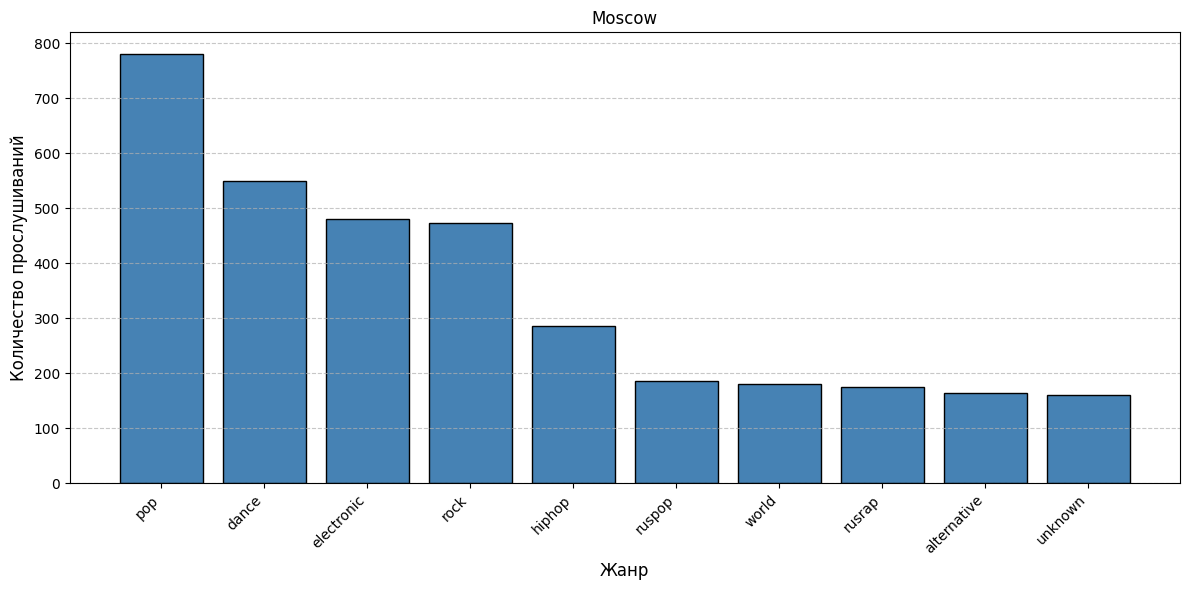

In [ ]:
data = genre_weekday(df, 'Monday', 'Moscow', '07:00:00', '11:00:00')
plot(data, 'Moscow')

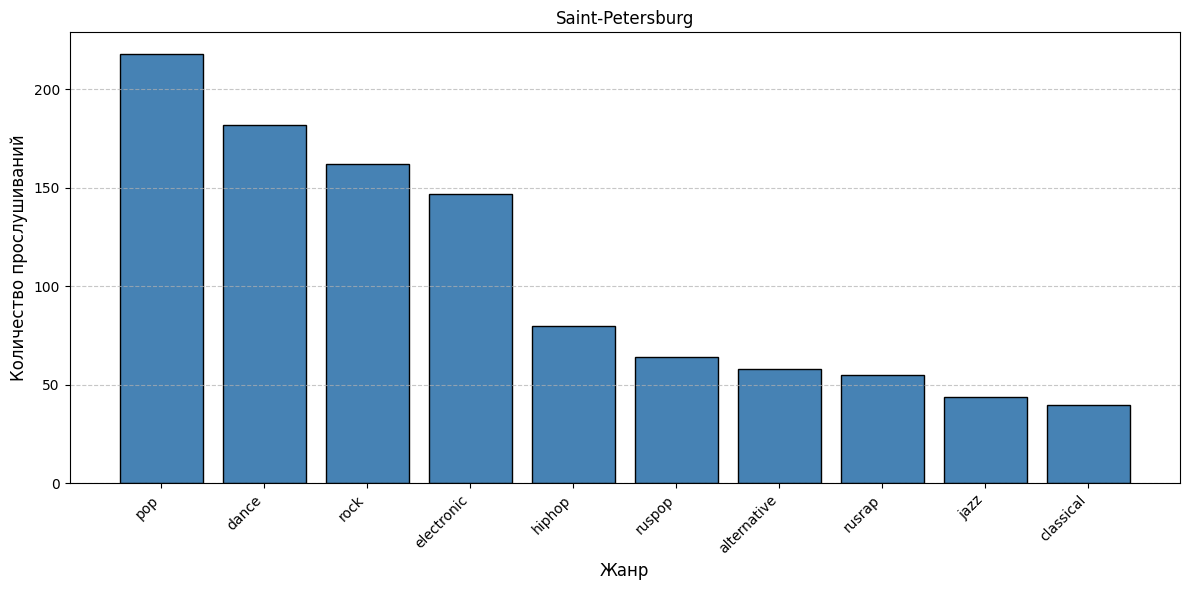

In [ ]:
data = genre_weekday(df, 'Monday', 'Saint-Petersburg', '07:00:00', '11:00:00')
plot(data, 'Saint-Petersburg')

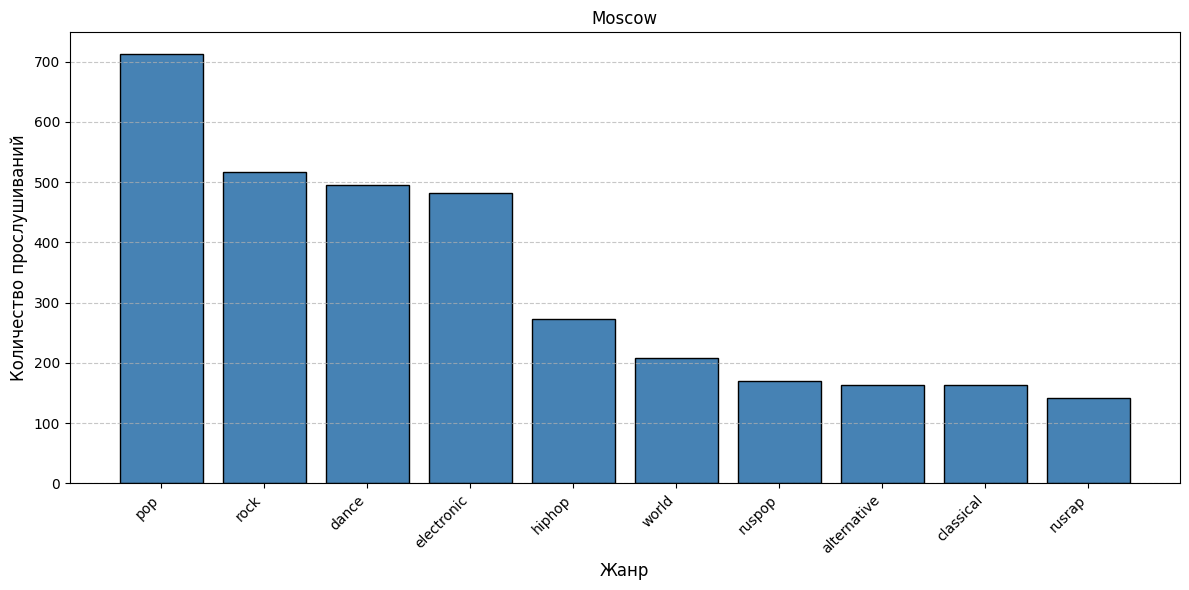

In [ ]:
data = genre_weekday(df, 'Friday', 'Moscow', '17:00:00', '23:59:00')
plot(data, 'Moscow')

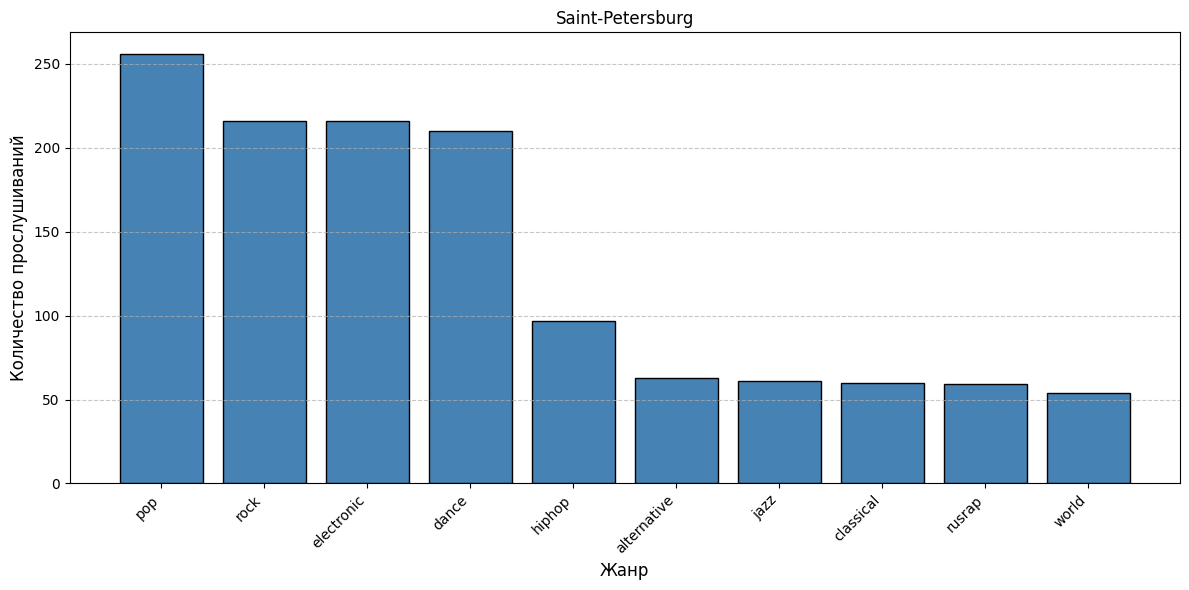

In [ ]:
data = genre_weekday(df, 'Friday', 'Saint-Petersburg', '17:00:00', '23:59:00')
plot(data, 'Saint-Petersburg')

Анализ предпочтений в понедельник утром показывает, что музыкальные вкусы жителей Москвы и Санкт-Петербурга во многом совпадают:  фаворитом в обоих городах становится поп-музыка. Однако если присмотреться к нижней части рейтинга (позиции 6–10), проявляются локальные особенности. Так, в санкт-петербургском топ-10 находят отклик джаз и классические композиции, тогда как московские пользователи чаще отдают предпочтение альтернативной музыке и русскоязычному рэпу.


Гипотезы подтвердились частично. Города действительно слушают музыку по-разному, но различия проявляются в деталях, а не в основе. Поп-музыка объединяет, а локальные предпочтения — дифференцируют. Это ценная информация как для аналитики, так и для продуктовой стратегии.